<a href="https://colab.research.google.com/github/Anil2801/lstm-stock-forecast/blob/main/stock_lstm_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/20


/tmp/ipykernel_3410/3770217863.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2018-01-01', end='2024-12-31', progress=False)


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0400
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0013
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0010
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0010
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 9.9995e-04
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 9.6896e-04
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 9.2575e-04
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 8.8443e-04
Epoch 9/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.4784e-04
Epoch 10/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 8.1327e-04
Epoch 11/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 7.8074e-04
Epoch 12/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 7.5265e-04
Epoch 13/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 7.3530e-04
Epoch 14/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7.2547e-04
Epoch 15/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 

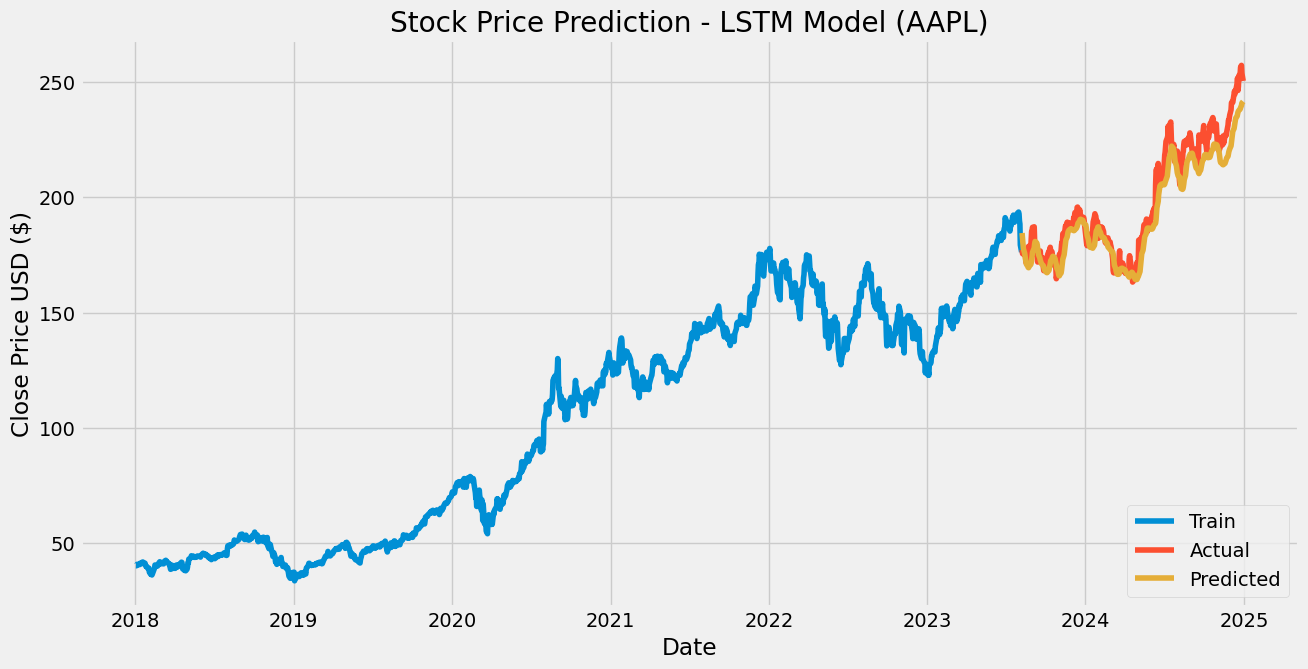

Predicted closing price for 31-12-2024: $241.66


In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM

plt.style.use('fivethirtyeight')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Load dataset
df = yf.download('AAPL', start='2018-01-01', end='2024-12-31', progress=False)

# Safely extract 'Close' column regardless of pandas/yfinance version
if isinstance(df.columns, pd.MultiIndex):
    data = df['Close'][['AAPL']].rename(columns={'AAPL': 'Close'})
else:
    data = df[['Close']]

dataset = data.values.reshape(-1, 1)

# 2. Train-test split (80% training, in time order)
training_data_len = int(len(dataset) * 0.8)

# 3. Scale the data
#    FIX: fit the scaler on the TRAINING portion only, so no information
#    from the test period leaks into training.
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(dataset[:training_data_len])
scaled_data = scaler.transform(dataset)

# 4. Create training dataset (60-day sliding window)
train_data = scaled_data[0:training_data_len]

x_train, y_train = [], []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# 5. Build & compile stacked LSTM model
model = Sequential([
    Input(shape=(x_train.shape[1], 1)),
    LSTM(50, return_sequences=True),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Train model
model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1)

# 7. Create test dataset & predict
test_data = scaled_data[training_data_len - 60:]

x_test = []
y_test = dataset[training_data_len:]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# 8. Evaluate: LSTM vs naive baseline
rmse_lstm = np.sqrt(np.mean((predictions - y_test) ** 2))

# Naive baseline: predict that tomorrow's close equals today's close
naive_pred = dataset[training_data_len - 1:-1]
rmse_naive = np.sqrt(np.mean((naive_pred - y_test) ** 2))

print(f"Naive baseline RMSE : {rmse_naive:.2f}")
print(f"LSTM RMSE           : {rmse_lstm:.2f}")
print(f"Test samples        : {len(y_test)}")

# 9. Plot results
train = data[:training_data_len]
valid = data[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(14, 7))
plt.title('Stock Price Prediction - LSTM Model (AAPL)')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train['Close'], label='Train')
plt.plot(valid['Close'], label='Actual')
plt.plot(valid['Predictions'], label='Predicted')
plt.legend(loc='lower right')
plt.savefig('predictions_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. Predict next trading day
last_60_days = data['Close'].tail(60).values.reshape(-1, 1)
last_60_scaled = scaler.transform(last_60_days)

X_next = np.array([last_60_scaled])
X_next = np.reshape(X_next, (X_next.shape[0], X_next.shape[1], 1))

pred_price_scaled = model.predict(X_next, verbose=0)
pred_price = scaler.inverse_transform(pred_price_scaled)[0][0]

last_date = pd.Timestamp(data.index[-1]).normalize()
next_trading_day = last_date + pd.tseries.offsets.BDay(1)

print(f"Predicted closing price for {next_trading_day.strftime('%d-%m-%Y')}: ${pred_price:.2f}")